# Section 1: Vectorized Linear Regression Engine from Scratch

**Objective:**
Construct the core optimization algorithms strictly via vectorized NumPy operations. Explicit loops (`for`/`while`) iterating through samples or features are strictly prohibited.

#### Step 1: Hypothesis & Cost Function
Complete `compute_cost` to evaluate the Mean Squared Error across all $m$ examples simultaneously:
$$J(\vec{w}, b) = \frac{1}{2m} \sum_{i=1}^m \left( f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)} \right)^2$$

In [1]:
import numpy as np

def compute_cost(X, y, w, b):
    m = len(y)
    # Compute linear predictions vector of shape (m,)
    predictions = X @ w + b
    
    # Compute vector of residuals
    residuals = predictions - y
    
    # Return scalar MSE cost
    cost = (1 / (2 * m)) * np.sum(residuals ** 2)
    return cost

#### Step 2: Vectorized Gradient Derivation
Compute $\frac{\partial J}{\partial \vec{w}}$ and $\frac{\partial J}{\partial b}$ across the batch using matrix-vector dot products.
Ensure `dj_dw` matches the shape of $\vec{w}$ (shape `(n,)`) and `dj_db` evaluates to a scalar.

In [2]:
def compute_gradient(X, y, w, b):
    m = len(y)
    # Vectorized residuals: shape (m,)
    residuals = (X @ w + b) - y
    
    # Matrix product yielding gradient vector of shape (n,)
    dj_dw = (1 / m) * (X.T @ residuals)
    
    # Scalar gradient with respect to bias
    dj_db = (1 / m) * np.sum(residuals)
    
    return dj_dw, dj_db

#### Step 3: Optimization Loop & Convergence Tracking
Execute iterative gradient updates with simultaneous parameter assignments and record history.

In [3]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iters):
    w = w_init.copy()
    b = b_init
    cost_history = []
    
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        
        # Simultaneous parameter updates
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        cost_history.append(compute_cost(X, y, w, b))
        
    return w, b, cost_history

#### Step 4: Analytical Verification (Sanity Check with Problem 2)
Feed the theoretical vehicle stopping calibration matrix into your function. Ensure your Epoch 1 and Epoch 2 outputs match your handwritten steps.

In [4]:
# Construct calibration matrix and vector from Problem 2
X_calib = np.array([
    [1.0, 0.0],
    [2.0, 1.0],
    [0.0, 1.0]
])
y_calib = np.array([2.0, 5.0, 3.0])

w_init = np.zeros(2)
b_init = 0.0
alpha = 0.1

# Run gradient descent for exactly 2 epochs
w_out, b_out, loss_hist = gradient_descent(X_calib, y_calib, w_init, b_init, alpha, num_iters=2)

print("Initial Cost J_0   :", round(compute_cost(X_calib, y_calib, w_init, b_init), 4))
print("Updated Weights w  :", np.round(w_out, 4))
print("Updated Bias b     :", round(b_out, 4))
print("Cost after Epoch 2 :", round(loss_hist[-1], 4))

Initial Cost J_0   : 6.3333
Updated Weights w  : [0.6822 0.4667]
Updated Bias b     : 0.5756
Cost after Epoch 2 : 1.8515


# Section 2: Non-Linear Mapping & Feature Normalization

**Objective:**
Transform 1D inputs into higher-dimensional polynomial feature spaces, implement stable Z-score normalization, and trace optimization dynamics.

#### Step 1: Polynomial Feature Matrix Formulation
Transform raw array `x` into a polynomial design matrix $\mathbf{X} = [x, x^2, x^3]$.

In [5]:
np.random.seed(42)
m = 80
x_raw = np.linspace(-2.5, 3.0, m)
noise = np.random.normal(0, 2.0, m)
y_true = 0.8 * (x_raw ** 3) - 1.5 * (x_raw ** 2) - 2.0 * x_raw + 5.0 + noise

# Construct 2D column arrays
col_x1 = x_raw.reshape(-1, 1)
col_x2 = (x_raw ** 2).reshape(-1, 1)
col_x3 = (x_raw ** 3).reshape(-1, 1)

# Stack horizontally along feature dimension
X_poly = np.hstack([col_x1, col_x2, col_x3])

print("Matrix Shape:", X_poly.shape)  # Expected: (80, 3)

Matrix Shape: (80, 3)


#### Step 2: Robust Z-Score Normalization
Implement feature-wise normalization: $X_{norm} = \frac{X - \mu}{\sigma + \epsilon}$.

In [6]:
def zscore_standardize(X):
    # Compute column-wise statistics
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    
    # Standardize with broadcast subtraction and division
    X_norm = (X - mu) / (sigma  + 1e-8)
    return X_norm, mu, sigma

X_norm, mu, sigma = zscore_standardize(X_poly)

print("Column Means :", np.round(np.mean(X_norm, axis=0), 2))
print("Column Stds  :", np.round(np.std(X_norm, axis=0), 2))

Column Means : [-0.  0. -0.]
Column Stds  : [1. 1. 1.]


#### Step 3: Gradient Descent Convergence & Learning Curve
Run 600 iterations on the normalized polynomial dataset and plot the loss trajectory.

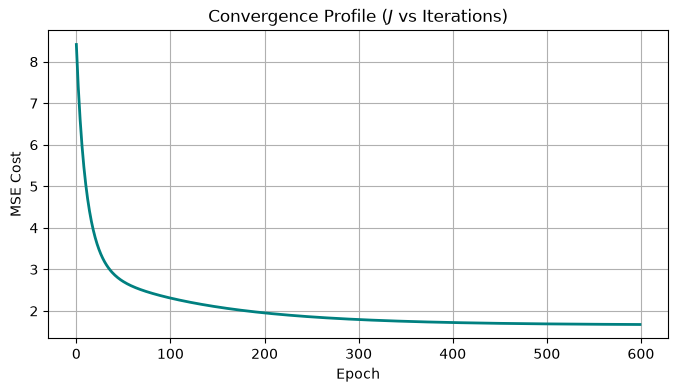

In [7]:
import matplotlib.pyplot as plt

w_init = np.zeros(3)
b_init = 0.0
alpha = 0.05
epochs = 600

w_poly, b_poly, cost_curve = gradient_descent(X_norm, y_true, w_init, b_init, alpha, epochs)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(epochs), cost_curve, color='teal', lw=2)
ax.set_title("Convergence Profile ($J$ vs Iterations)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Cost")
ax.grid(True)
plt.show()

#### Step 4: Regression Curve Overlay
Generate continuous predictions across sorted inputs to plot a smooth curve.

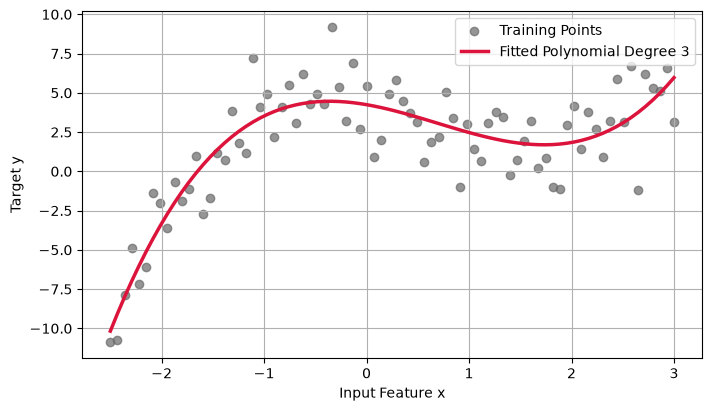

In [8]:
# Compute model predictions on the normalized dataset
y_preds = X_norm @ w_poly + b_poly

# Obtain sort indices according to raw x values
sort_order = np.argsort(x_raw)

plt.figure(figsize=(8, 4.5))
plt.scatter(x_raw, y_true, color='dimgray', alpha=0.7, label='Training Points')
plt.plot(x_raw[sort_order], y_preds[sort_order], color='crimson', lw=2.5, label='Fitted Polynomial Degree 3')
plt.xlabel("Input Feature x")
plt.ylabel("Target y")
plt.legend()
plt.grid(True)
plt.show()

# Section 3: Industry Benchmarking & Pipeline Integration

**Objective:**
Replicate the full transformation and fitting workflow using Scikit-Learn pipelines, and quantitatively benchmark predictions.

#### Step 1: Scikit-Learn Model Training

In the lectures, we derived the batch gradient descent algorithm from first principles. When moving to production libraries like `scikit-learn`, these same concepts are implemented under standard estimator interfaces:
* `LinearRegression`: Solves for parameters analytically using the closed-form Ordinary Least Squares (OLS) / Normal Equation.
* `SGDRegressor`: Implements iterative gradient descent optimization. By setting `penalty=None` and choosing a fixed learning rate (`learning_rate='constant'`), it directly mirrors our custom gradient descent loop.

> **Recommended Reference:** If you haven't already, check out the optional course notebook:  
> **`Optional lab: Linear regression with scikit-learn`**  
> It walks through these exact two estimators and shows how production APIs handle parameter tracking (`.coef_` and `.intercept_`).

**Your Mission:** Fit both estimators on your normalized polynomial design matrix (`X_norm`, `y_true`).

In [9]:
from sklearn.linear_model import LinearRegression, SGDRegressor

# 1. Closed-form OLS estimator
lr_model = LinearRegression()
lr_model.fit(X_norm, y_true)

# 2. Iterative SGD with matching hyperparameter configuration
sgd_model = SGDRegressor(max_iter=600, eta0=0.05, learning_rate='constant', penalty=None, random_state=42)
sgd_model.fit(X_norm, y_true)

print("Scratch Engine Weights:", np.round(w_poly, 3), "| Bias:", round(float(b_poly), 3))
print("Sklearn OLS Weights   :", np.round(lr_model.coef_, 3), "| Bias:", round(float(lr_model.intercept_), 3))
print("Sklearn SGD Weights   :", np.round(sgd_model.coef_, 3), "| Bias:", round(float(sgd_model.intercept_[0]), 3))

Scratch Engine Weights: [-1.818 -3.052  5.211] | Bias: 1.845
Sklearn OLS Weights   : [-2.183 -3.134  5.613] | Bias: 1.845
Sklearn SGD Weights   : [-2.145 -3.053  5.773] | Bias: 1.928


#### Step 2: Quantitative Metric Comparison
Implement RMSE from scratch and confirm alignment with Scikit-Learn's metric.

In [10]:
from sklearn.metrics import mean_squared_error

# Calculate scratch RMSE using elementary NumPy operations
scratch_rmse = np.sqrt(np.mean((y_preds - y_true) ** 2))

# Calculate Scikit-Learn RMSE
sklearn_rmse = np.sqrt(mean_squared_error(y_true, lr_model.predict(X_norm)))

print(f"Scratch Engine RMSE : {scratch_rmse:.4f}")
print(f"Scikit-Learn RMSE   : {sklearn_rmse:.4f}")

# Discrepancy assertion
diff = np.abs(scratch_rmse - sklearn_rmse)
print(f"Absolute Discrepancy: {diff:.6f}")
assert diff < 0.05, "Convergence mismatch exceeds acceptable threshold!"

Scratch Engine RMSE : 1.8293
Scikit-Learn RMSE   : 1.8227
Absolute Discrepancy: 0.006597
